In [ ]:
import pandas as pd

## Data Loading and Initial Inspection

Let's load the `Salary_dataset.csv` file and take a first look at its structure and content.

In [ ]:
df = pd.read_csv('/content/Salary_dataset.csv')
display(df.head())

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


### Check Data Information and Missing Values

Next, we'll examine the data types, non-null counts, and descriptive statistics. We'll also identify any missing values in each column.

In [ ]:
print(df.info())
print("\nDescriptive Statistics:")
display(df.describe())
print("\nMissing values per column:")
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None

Descriptive Statistics:


,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000



Missing values per column:


,0
Unnamed: 0,0
YearsExperience,0
Salary,0


### Removing Redundant Column

The `Unnamed: 0` column seems to be a redundant index. Let's drop it to clean up the DataFrame.

In [ ]:
df = df.drop('Unnamed: 0', axis=1)
display(df.head())

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [ ]:
df.tail()

,YearsExperience,Salary
25,9.1,105583.0
26,9.6,116970.0
27,9.7,112636.0
28,10.4,122392.0
29,10.6,121873.0


### Checking and Removing Duplicate Rows

Duplicate rows can skew analysis and model training. Let's check if there are any duplicate entries and remove them to ensure data integrity.

In [ ]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0


## Exploratory Data Analysis (EDA)

Now that the data is clean, let's explore its characteristics. We'll start by visualizing the distribution of each numerical variable.

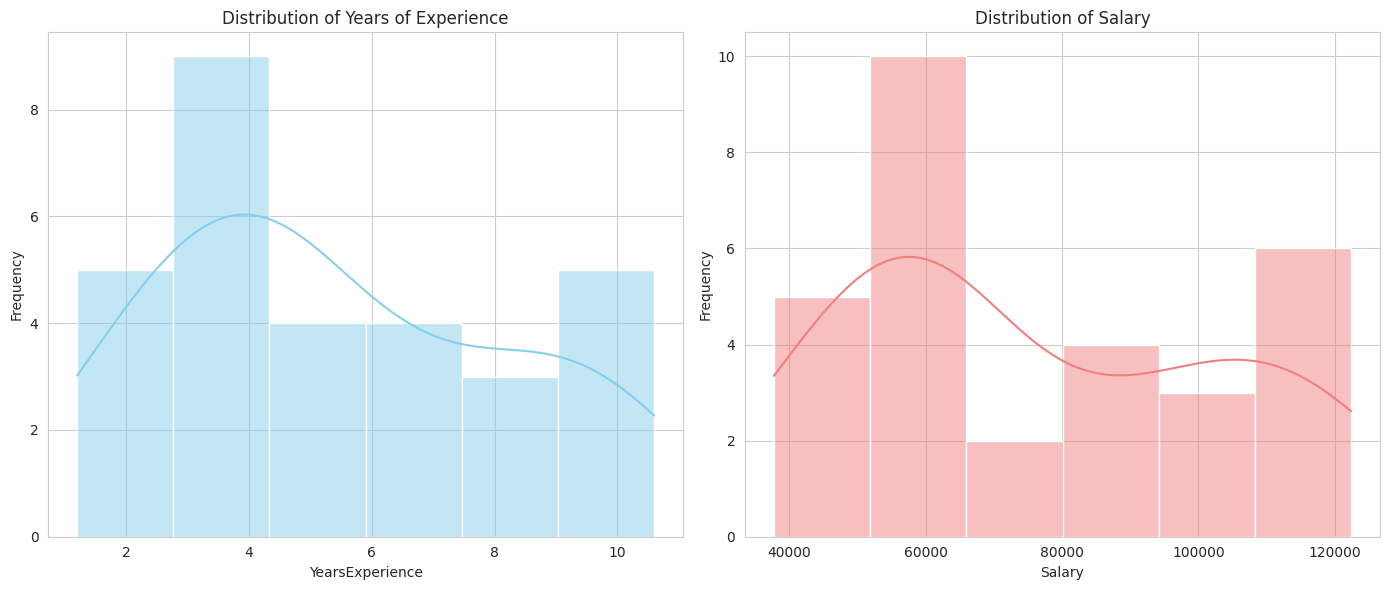

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
sns.set_style('whitegrid')

# Create subplots for YearsExperience and Salary histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram for YearsExperience
sns.histplot(df['YearsExperience'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Years of Experience')
axes[0].set_xlabel('YearsExperience')
axes[0].set_ylabel('Frequency')

# Histogram for Salary
sns.histplot(df['Salary'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Salary')
axes[1].set_xlabel('Salary')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Relationship between YearsExperience and Salary

Next, let's visualize the relationship between 'YearsExperience' and 'Salary' using a scatter plot. This will help us identify any trends or correlations.

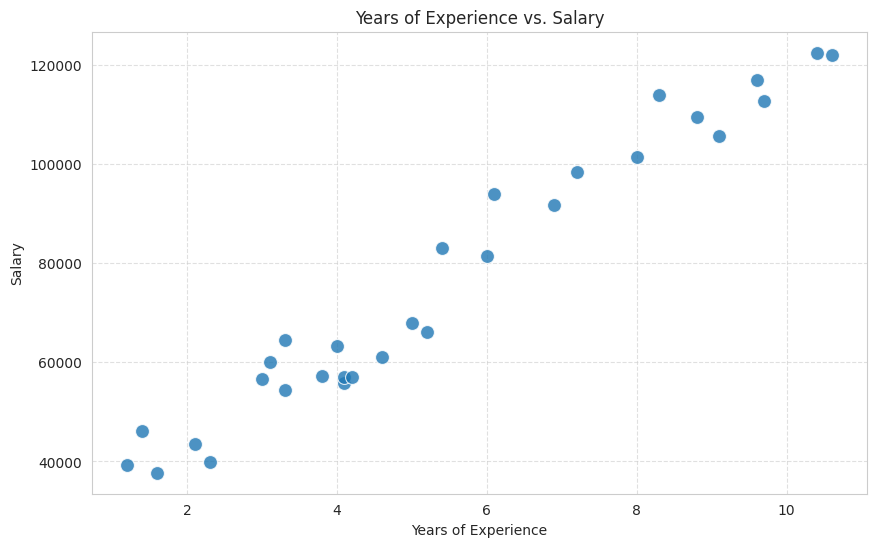

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='YearsExperience', y='Salary', data=df, s=100, alpha=0.8)
plt.title('Years of Experience vs. Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

From these plots, we can observe the distributions of each variable and the general relationship between them. This linear relationship suggests that a simple linear regression model might be suitable for predicting salary based on years of experience.

### Saving Data in Pickle Format

To save the cleaned and explored DataFrame for future use, we can serialize it into a pickle file. This preserves the DataFrame's structure and data types efficiently.

## Model Building: Linear Regression

Given the clear linear relationship observed between 'YearsExperience' and 'Salary', a Linear Regression model is a suitable choice for this predictive task. We will split our data into training and testing sets, train the model, and then evaluate its performance.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = df[['YearsExperience']]
y = df['Salary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 24 samples
Test set size: 6 samples


### Training the Linear Regression Model

Now, let's train the Linear Regression model using our training data.

In [ ]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Model Intercept: {model.intercept_:.2f}")
print(f"Model Coefficient (YearsExperience): {model.coef_[0]:.2f}")

Model Intercept: 24380.20
Model Coefficient (YearsExperience): 9423.82


### Model Evaluation

Finally, we'll evaluate the model's performance on the test set using common regression metrics.

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 6286.45
Mean Squared Error (MSE): 49830096.86
Root Mean Squared Error (RMSE): 7059.04
R-squared (R2): 0.90


### Visualizing Model Predictions

Let's visualize the regression line against the actual data points.

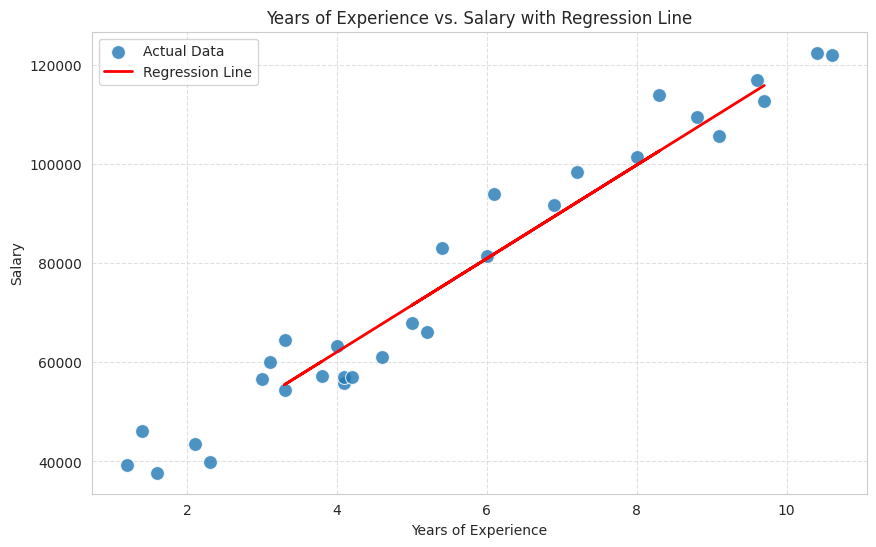

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='YearsExperience', y='Salary', data=df, s=100, alpha=0.8, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Years of Experience vs. Salary with Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
import pickle

# Define the filename for the pickle file
filename = 'salary_data.pkl'

# Save the DataFrame to a pickle file
with open(filename, 'wb') as file:
    pickle.dump(df, file)

print(f"DataFrame successfully saved to {filename}")

DataFrame successfully saved to salary_data.pkl
